In [1]:
# Import packages and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [2]:
# Check the version of XGBoost
print("Found XGBoost v" + xgboost.__version__)

Found XGBoost v2.1.4


In [3]:
datasetPath = "dataset/10p/all/kernel3/"

In [4]:
# Parameters
datasetPath = "dataset/mask5/10p/glrlm/kernel5/"


In [5]:
# train/validation/test = 70/10/20
train_data = pd.read_csv(f"{datasetPath}dataset.train.csv")
validation_data = pd.read_csv(f"{datasetPath}dataset.validation.csv")
test_data = pd.read_csv(f"{datasetPath}dataset.test.csv")

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights on the training set
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_data["label"]
)
class_weight = dict(zip(classes, weights))

# Prepare features and sample weights for XGBoost
feature_cols = [
    col for col in train_data.columns
    if col not in ["label", "sample_weight"]
]
X_train = train_data[feature_cols]
y_train = train_data["label"].astype(int)
X_val = validation_data[feature_cols]
y_val = validation_data["label"].astype(int)
X_test = test_data[feature_cols]
y_test = test_data["label"].astype(int)

train_weight = y_train.map(class_weight).to_numpy()
val_weight = y_val.map(class_weight).to_numpy()
test_weight = y_test.map(class_weight).to_numpy()

In [7]:
# XGBClassifier uses the pandas data prepared above

In [8]:
%%time

# Train an XGBoost binary classification model.
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    sample_weight=train_weight,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    sample_weight_eval_set=[train_weight, val_weight],
    verbose=False
)

CPU times: user 7.54 s, sys: 57.8 ms, total: 7.6 s
Wall time: 759 ms


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['logloss', 'auc'],
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [9]:
# Evaluate the model on the validation set
from sklearn.metrics import accuracy_score, roc_auc_score

val_probs = model.predict_proba(X_val)[:, 1]
val_pred = (val_probs >= 0.5).astype(int)

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Validation ROC AUC: {roc_auc_score(y_val, val_probs):.4f}")

Validation accuracy: 0.9861
Validation ROC AUC: 0.9971


In [10]:
# Model summary
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['logloss', 'auc'],
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)


In [11]:
# Model features
feature_cols

['GrayLevelNonUniformity',
 'GrayLevelNonUniformityNormalized',
 'GrayLevelVariance',
 'HighGrayLevelRunEmphasis',
 'LongRunEmphasis',
 'LongRunHighGrayLevelEmphasis',
 'LongRunLowGrayLevelEmphasis',
 'LowGrayLevelRunEmphasis',
 'RunEntropy',
 'RunLengthNonUniformity',
 'RunLengthNonUniformityNormalized',
 'RunPercentage',
 'RunVariance',
 'ShortRunEmphasis',
 'ShortRunHighGrayLevelEmphasis',
 'ShortRunLowGrayLevelEmphasis']

LongRunHighGrayLevelEmphasis        0.234688
HighGrayLevelRunEmphasis            0.186601
ShortRunHighGrayLevelEmphasis       0.082429
RunEntropy                          0.050380
LongRunEmphasis                     0.046912
ShortRunLowGrayLevelEmphasis        0.045045
RunLengthNonUniformityNormalized    0.044774
LowGrayLevelRunEmphasis             0.039450
GrayLevelNonUniformityNormalized    0.039385
RunLengthNonUniformity              0.036270
LongRunLowGrayLevelEmphasis         0.035333
RunPercentage                       0.034192
ShortRunEmphasis                    0.033593
GrayLevelNonUniformity              0.032597
RunVariance                         0.030011
GrayLevelVariance                   0.028340
dtype: float32


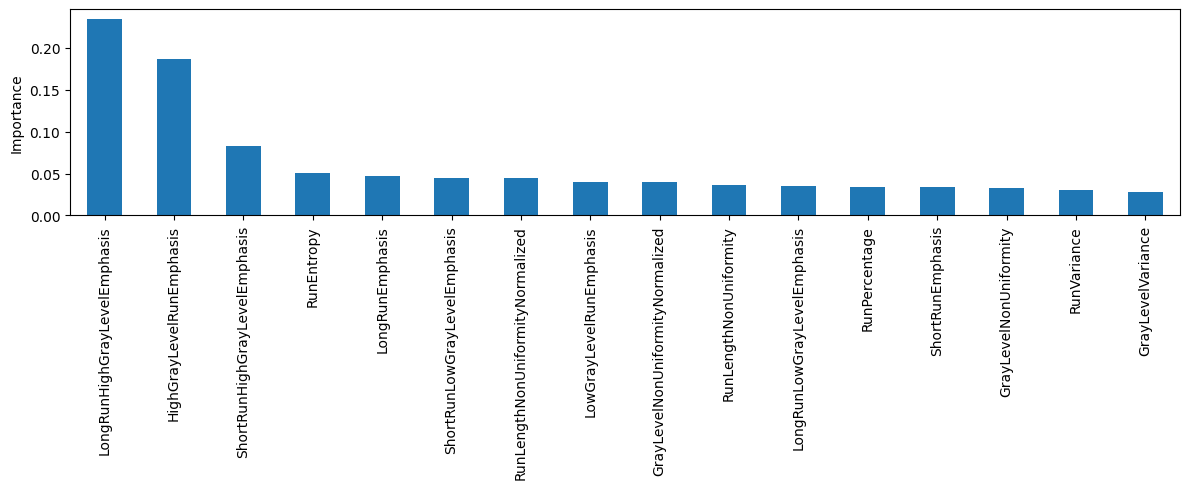

In [12]:
# Feature importance
feature_importance = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)

print(feature_importance.head(20))
feature_importance.head(20).plot.bar(figsize=(12, 5))
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [13]:
# Model attributes
model.get_booster().attributes()

{}

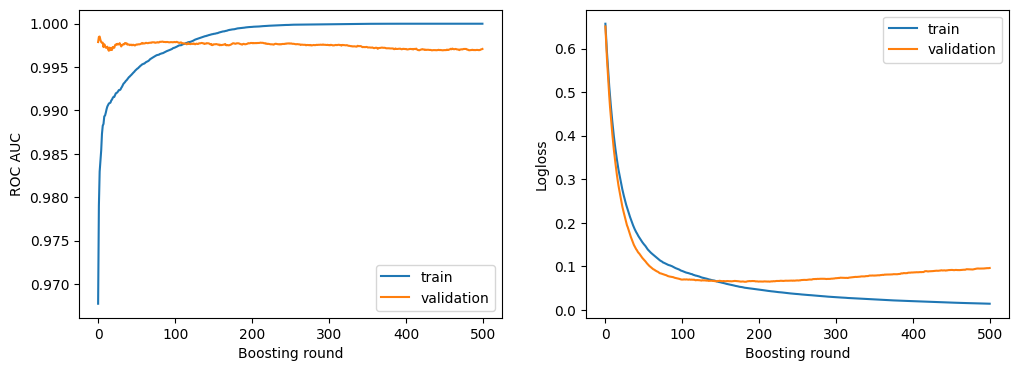

In [14]:
results = model.evals_result()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(results["validation_0"]["auc"], label="train")
plt.plot(results["validation_1"]["auc"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("ROC AUC")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("Logloss")
plt.legend()
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict_proba(X_val)[:, 1]
y_true = y_val

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC)

The ROC AUC score is 0.99709


In [16]:
# Compute binary classification metrics with sklearn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get positive-class probabilities and convert them to labels
pos_probs = model.predict_proba(X_test)[:, 1]
y_pred = (pos_probs >= 0.5).astype(int)
y_true = y_test.to_numpy()

metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)
metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0, 1])
metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

Sklearn binary metrics:
accuracy: 0.9636
precision: 0.8789
recall: 0.7357
f1: 0.8010
mcc: 0.7849
roc_auc: 0.9597
pr_auc: 0.8588
log_loss: 0.1360
brier_score: 0.0298

Confusion matrix:
 [[2033   23]
 [  60  167]]

Classification report:
               precision    recall  f1-score   support

           0     0.9713    0.9888    0.9800      2056
           1     0.8789    0.7357    0.8010       227

    accuracy                         0.9636      2283
   macro avg     0.9251    0.8622    0.8905      2283
weighted avg     0.9621    0.9636    0.9622      2283

